poi=1

In [1]:
import numpy as np
import time
import json

from numba import njit, prange

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle


# =========================================================
# CONSTANTS
# =========================================================

KYBER_Q = 3329
QINV = -3327

HW_LOOKUP = np.array(
    [bin(i).count("1") for i in range(256)],
    dtype=np.uint8
)


# =========================================================
# EXACT KYBER ARITHMETIC (NUMBA JIT)
# =========================================================

@njit(inline='always')
def int16_numba(x):
    x = x & 0xFFFF
    return x - 0x10000 if x & 0x8000 else x


@njit(inline='always')
def uint16_numba(x):
    return x & 0xFFFF


@njit(inline='always')
def montgomery_reduce_numba(a):

    t = int16_numba(a)

    t = int16_numba(t * QINV)

    res = (a - (int(t) * KYBER_Q)) >> 16

    return int16_numba(res)


@njit(inline='always')
def fqmul_numba(a, b):

    prod = int16_numba(a) * int16_numba(b)

    return uint16_numba(
        montgomery_reduce_numba(prod)
    )


# =========================================================
# FAST PARALLEL fqmul COMPUTATION
# =========================================================

@njit(parallel=True)
def compute_prod_chunk(
    nonce_b,
    g_chunk,
    att,
    cols
):

    prod_chunk = np.empty(
        (att, cols),
        dtype=np.uint16
    )

    for j in prange(att):

        b = int(nonce_b[j])

        for k in range(cols):

            prod_chunk[j, k] = fqmul_numba(
                int(g_chunk[k]),
                b
            )

    return prod_chunk


# =========================================================
# FAST PARALLEL LOG-LIKELIHOOD
# =========================================================

@njit(parallel=True)
def compute_tot_loglike(
    class_chunk,
    logprobs,
    att,
    cols
):

    out = np.zeros(cols, dtype=np.float64)

    for k in prange(cols):

        s = 0.0

        for j in range(att):

            s += logprobs[j, class_chunk[j, k]]

        out[k] = s

    return out


# =========================================================
# LOADERS
# =========================================================

def load_traces(path):

    traces = np.load(path)

    return traces.astype(np.float32)


def load_nonces(path):

    nonces = np.load(path)

    if nonces.dtype == np.uint8:

        if nonces.shape[1] % 2 != 0:

            raise ValueError(
                "Nonce byte array must have even number of columns"
            )

        nonces16 = (
            nonces[:, ::2].astype(np.uint16)
            +
            (
                nonces[:, 1::2].astype(np.uint16)
                << 8
            )
        )

        return nonces16

    return nonces.astype(np.uint16)


# =========================================================
# TRACE COMPRESSION
# =========================================================

def compress(raw, cf):

    N, L = raw.shape

    CL = (L + cf - 1) // cf

    out = np.zeros((N, CL), dtype=np.float32)

    for i in range(CL):

        start = i * cf

        end = min(L, (i + 1) * cf)

        out[:, i] = raw[:, start:end].mean(axis=1)

    return out


# =========================================================
# POI SELECTION
# =========================================================

def compute_between_class_poi_score(
    traces,
    labels,
    prof
):

    Xp = traces[:prof]

    labs = labels[:prof]

    mu_all = Xp.mean(axis=0)

    score = np.zeros(
        Xp.shape[1],
        dtype=np.float64
    )

    classes = np.unique(labs)

    for c in classes:

        mask = labs == c

        if np.sum(mask) == 0:
            continue

        mu_c = Xp[mask].mean(axis=0)

        diff = (mu_c - mu_all) ** 2

        score += diff

    return score


# =========================================================
# MAIN ATTACK
# =========================================================

def attack_rf_hw_multiclass(

    traces,
    nonces,
    prof,
    NUM_POI,
    which,
    chunk=1024,
    rf_n_estimators=100,
    rf_n_jobs=-1,
    random_state=0,

):

    N = traces.shape[0]

    att = N - prof

    if att <= 0:

        raise ValueError(
            "Number of attack traces is zero or negative."
        )

    idx = 2 if which == 0 else 5

    # =====================================================
    # LABELS
    # =====================================================

    labels = np.zeros(
        prof,
        dtype=np.int8
    )

    for i in range(prof):

        val = int(nonces[i, idx])

        msb = (val >> 8) & 0xFF

        labels[i] = int(HW_LOOKUP[msb])

    # =====================================================
    # POI SELECTION
    # =====================================================

    score = compute_between_class_poi_score(
        traces,
        labels,
        prof
    )

    pois = np.argsort(-score)[:NUM_POI]

    # =====================================================
    # TRAIN RF
    # =====================================================

    X_train = traces[:prof, pois]

    scaler = StandardScaler()

    X_train_s = scaler.fit_transform(
        X_train
    )

    clf = RandomForestClassifier(

        n_estimators=rf_n_estimators,

        n_jobs=rf_n_jobs,

        random_state=random_state

    )

    clf.fit(X_train_s, labels)

    # =====================================================
    # ATTACK PHASE
    # =====================================================

    X_attack = traces[prof:, pois]

    X_attack_s = scaler.transform(
        X_attack
    )

    probs = clf.predict_proba(
        X_attack_s
    )

    probs = np.clip(
        probs,
        1e-15,
        1.0
    )

    logprobs = np.log(probs)

    nonce_b = nonces[
        prof:,
        1
    ].astype(np.int64)

    guesses = np.arange(
        65536,
        dtype=np.int64
    )

    all_scores = np.full(
        65536,
        -np.inf,
        dtype=np.float64
    )

    # =====================================================
    # BUILD HW -> CLASS MAP ONCE
    # =====================================================

    classes_present = np.asarray(
        clf.classes_,
        dtype=np.int16
    )

    hw_to_col = np.empty(
        256,
        dtype=np.int64
    )

    for hw_val in range(256):

        diffs = np.abs(
            classes_present - hw_val
        )

        hw_to_col[hw_val] = np.argmin(diffs)

    # =====================================================
    # CHUNK PROCESSING
    # =====================================================

    for start in range(0, 65536, chunk):

        end = min(start + chunk, 65536)

        g_chunk = guesses[start:end]

        cols = g_chunk.shape[0]

        # -------------------------------------------------
        # PARALLEL fqmul
        # -------------------------------------------------

        prod_chunk = compute_prod_chunk(

            nonce_b,
            g_chunk,
            att,
            cols

        )

        # -------------------------------------------------
        # MSB + HW
        # -------------------------------------------------

        msb_chunk = (
            (prod_chunk >> 8) & 0xFF
        ).astype(np.uint8)

        hw_chunk = HW_LOOKUP[
            msb_chunk
        ]

        # -------------------------------------------------
        # CLASS INDEX
        # -------------------------------------------------

        class_chunk = hw_to_col[
            hw_chunk
        ]

        # -------------------------------------------------
        # PARALLEL LOG-LIKELIHOOD
        # -------------------------------------------------

        tot_loglike = compute_tot_loglike(

            class_chunk,
            logprobs,
            att,
            cols

        )

        all_scores[start:end] = tot_loglike

    return all_scores


# =========================================================
# RANK FUNCTION
# =========================================================

def tie_inclusive_rank(
    all_scores,
    true_guess_index
):

    true_score = all_scores[
        int(true_guess_index)
    ]

    return int(
        np.sum(all_scores >= true_score)
    )


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":

    traces_file = "traces.npy"

    nonces_file = "nonces.npy"

    compressF = 10

    NUM_POI = 1

    profFrac = 0.8

    CHUNK = 1024

    RANDOM_STATE = 42

    print(
        "\n--- Optimized ML Attack ---\n"
    )

    # =====================================================
    # LOAD
    # =====================================================

    raw = load_traces(traces_file)

    nonces = load_nonces(nonces_file)

    raw, nonces = shuffle(

        raw,
        nonces,

        random_state=RANDOM_STATE

    )

    N_total = min(

        raw.shape[0],
        nonces.shape[0]

    )

    raw = raw[:N_total]

    nonces = nonces[:N_total]

    results = []

    # =====================================================
    # MAIN LOOP
    # =====================================================

    for N in range(300, 2301, 50):

        if N > len(raw):

            print(
                f"{N} SKIPPED"
            )

            continue

        print(f"Running N={N}")

        raw_subset = raw[:N]

        nonces_subset = nonces[:N]

        traces = compress(
            raw_subset,
            compressF
        )

        prof = max(
            1,
            int(profFrac * N)
        )

        att = N - prof

        # =================================================
        # ATTACK TIMER
        # =================================================

        t_start = time.process_time()

        scores_a0 = attack_rf_hw_multiclass(

            traces,
            nonces_subset,

            prof,

            NUM_POI,

            which=0,

            chunk=CHUNK,

            rf_n_estimators=100,

            rf_n_jobs=-1,

            random_state=RANDOM_STATE,

        )

        scores_a1 = attack_rf_hw_multiclass(

            traces,
            nonces_subset,

            prof,

            NUM_POI,

            which=1,

            chunk=CHUNK,

            rf_n_estimators=100,

            rf_n_jobs=-1,

            random_state=RANDOM_STATE,

        )

        t_end = time.process_time()

        cpu_time = t_end - t_start

        # =================================================
        # TRUE KEYS
        # =================================================

        true0 = int(
            nonces_subset[0, 0]
        )

        true1 = int(
            nonces_subset[0, 3]
        )

        # =================================================
        # RANKS
        # =================================================

        rank_a0 = tie_inclusive_rank(
            scores_a0,
            true0
        )

        rank_a1 = tie_inclusive_rank(
            scores_a1,
            true1
        )

        # =================================================
        # SAVE RESULTS
        # =================================================

        result = {

            "N": int(N),

            "prof": int(prof),

            "att": int(att),

            "rank_a0": int(rank_a0),

            "rank_a1": int(rank_a1),

            "cpu_time": float(cpu_time),

        }

        results.append(result)

        print(result)

    # =====================================================
    # SAVE JSON
    # =====================================================

    with open(
        "attack_results_1.json",
        "w"
    ) as f:

        json.dump(
            results,
            f,
            indent=4
        )

    print(
        "\nResults saved to attack_results_1.json"
    )


--- Optimized ML Attack ---

Running N=300
{'N': 300, 'prof': 240, 'att': 60, 'rank_a0': 2, 'rank_a1': 2, 'cpu_time': 3.859375}
Running N=350
{'N': 350, 'prof': 280, 'att': 70, 'rank_a0': 3, 'rank_a1': 2, 'cpu_time': 1.203125}
Running N=400
{'N': 400, 'prof': 320, 'att': 80, 'rank_a0': 3, 'rank_a1': 1, 'cpu_time': 1.5625}
Running N=450
{'N': 450, 'prof': 360, 'att': 90, 'rank_a0': 2, 'rank_a1': 1, 'cpu_time': 1.734375}
Running N=500
{'N': 500, 'prof': 400, 'att': 100, 'rank_a0': 1, 'rank_a1': 1, 'cpu_time': 2.734375}
Running N=550
{'N': 550, 'prof': 440, 'att': 110, 'rank_a0': 1, 'rank_a1': 3, 'cpu_time': 2.078125}
Running N=600
{'N': 600, 'prof': 480, 'att': 120, 'rank_a0': 3, 'rank_a1': 2, 'cpu_time': 1.984375}
Running N=650
{'N': 650, 'prof': 520, 'att': 130, 'rank_a0': 2, 'rank_a1': 2, 'cpu_time': 2.375}
Running N=700
{'N': 700, 'prof': 560, 'att': 140, 'rank_a0': 2, 'rank_a1': 2, 'cpu_time': 3.078125}
Running N=750
{'N': 750, 'prof': 600, 'att': 150, 'rank_a0': 2, 'rank_a1': 1, '

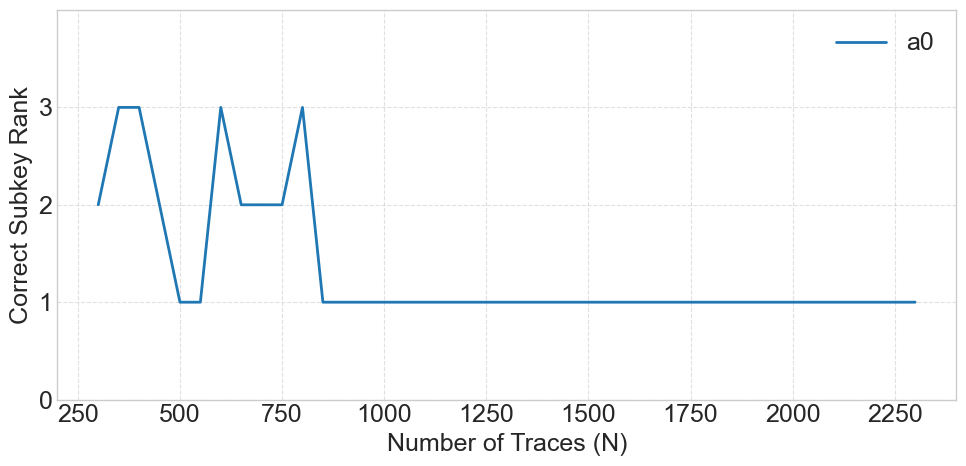

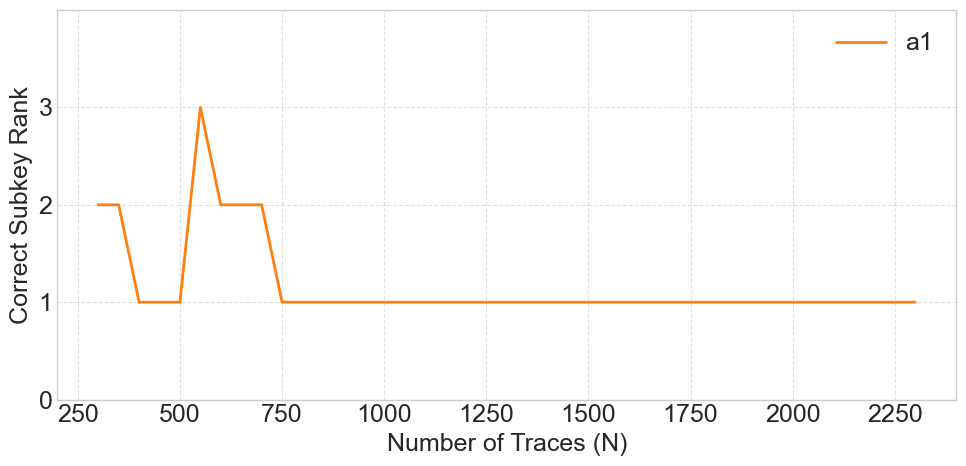

In [2]:
import matplotlib.pyplot as plt

# 1. Global font settings to match your BSS score plots
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
})

plt.style.use('seaborn-v0_8-whitegrid')

# Extract data from results
Ns = [r["N"] for r in results]
rank_a0 = [r["rank_a0"] for r in results]
rank_a1 = [r["rank_a1"] for r in results]

# --- Figure 1: Rank vs N for a₀ ---
# Removed 'marker' for a plain line
plt.figure(figsize=(10, 5))
plt.plot(Ns, rank_a0, color='tab:blue', linewidth=2, label='a0')
plt.xlabel("Number of Traces (N)")
plt.ylabel("Correct Subkey Rank")
plt.yticks([0, 1, 2, 3])
plt.ylim(0, 4)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("rank_a0_1analysis.pdf", format="pdf", bbox_inches='tight')
plt.show()

# --- Figure 2: Rank vs N for a₁ ---
# Removed 'marker' for a plain line
plt.figure(figsize=(10, 5))
plt.plot(Ns, rank_a1, color='tab:orange', linewidth=2, label='a1')
plt.xlabel("Number of Traces (N)")
plt.ylabel("Correct Subkey Rank")
plt.yticks([0, 1, 2, 3])
plt.ylim(0, 4)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("rank_a1_1analysis.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [3]:
# =========================================================
# VERIFY fqmul CORRECTNESS
# =========================================================

import numpy as np

correct_c0 = 0
correct_c1 = 0

total = len(nonces)

for i in range(total):

    a0 = int(nonces[i, 0])
    a1 = int(nonces[i, 3])

    b0 = int(nonces[i, 1])

    # expected values from dataset
    c0 = int(nonces[i, 2])
    c1 = int(nonces[i, 5])

    # recomputed values
    calc_c0 = fqmul_numba(a0, b0)
    calc_c1 = fqmul_numba(a1, b0)

    if calc_c0 == c0:
        correct_c0 += 1

    if calc_c1 == c1:
        correct_c1 += 1

# =========================================================
# ACCURACY
# =========================================================

acc_c0 = 100.0 * correct_c0 / total
acc_c1 = 100.0 * correct_c1 / total

print("\n===== fqmul Verification =====\n")

print(f"Total Samples : {total}")

print(f"\nc0 Verification:")
print(f"Correct = {correct_c0}")
print(f"Accuracy = {acc_c0:.4f}%")

print(f"\nc1 Verification:")
print(f"Correct = {correct_c1}")
print(f"Accuracy = {acc_c1:.4f}%")


===== fqmul Verification =====

Total Samples : 100000

c0 Verification:
Correct = 100000
Accuracy = 100.0000%

c1 Verification:
Correct = 100000
Accuracy = 100.0000%
